- ## Packages

In [5]:
pip install -q pyccl emantis baccoemu 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


- ## Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import pyccl as ccl
import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
from scipy.interpolate import interp1d
from scipy.integrate import simpson
import os
from contextlib import redirect_stdout, redirect_stderr
from lsst_galaxy_sample import LSSTGalaxySample as lsst

warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)


- ## Configuration

In [6]:
class Config:
    
    COSMO_PARAMS = {
        "Omega_m": 0.315,
        "Omega_b": 0.05,
        "h": 0.67,
        "n_s": 0.96,
        "sigma8": 0.83,
        "M_nu": 0.0,
        "w0": -1.0,
        "wa": 0.0,
        "aexp": 1.0
    }
    
    TRANSFER_FUNCTION = "boltzmann_camb"
    
    C_LIGHT = 299792.458
    
    Z_MIN = 0.01
    Z_MAX = 3.5
    N_Z = 500
    
    ELL_MIN = 10
    ELL_MAX = 2000
    N_ELL = 50
    
    BIAS_B0 = 2.0
    BIAS_BETA = 0.5
    
    FR_VALUES = [4, 5, 6]
    
    LSST_YEARS = ["1", "4", "7", "10"]
    LSST_BINS = [0, 1, 2]
    
    BACCO_K_MIN = -2
    BACCO_K_MAX = None
    BACCO_N_K = 200
    EMANTIS_VERBOSE = False
    
    FIGURE_SIZE = (16, 12)
    
    K_MIN_SAFETY = 1.1
    K_MAX_SAFETY = 0.9
    K_CLIP_THRESHOLD = 0.05

- ## Cosmology Utilities

In [7]:
def comoving_distance(z, cosmo):
    if np.isscalar(z):
        a = 1.0 / (1.0 + z)
        return ccl.comoving_radial_distance(cosmo, a) * cosmo['h']
    else:
        a = 1.0 / (1.0 + np.asarray(z))
        return ccl.comoving_radial_distance(cosmo, a) * cosmo['h']


def hubble_parameter(z, cosmo, H0):
    if np.isscalar(z):
        a = 1.0 / (1.0 + z)
        h_over_h0 = ccl.background.h_over_h0(cosmo, a)
        return H0 * h_over_h0
    else:
        a = 1.0 / (1.0 + np.asarray(z))
        h_over_h0 = ccl.background.h_over_h0(cosmo, a)
        return H0 * h_over_h0


def growth_factor(z, cosmo):
    if np.isscalar(z):
        a = 1.0 / (1.0 + z)
        return ccl.background.growth_factor(cosmo, a)
    else:
        a = 1.0 / (1.0 + np.asarray(z))
        return ccl.background.growth_factor(cosmo, a)


def validate_growth_factor(z_grid, D_vals, D0):
    if abs(D0 - 1.0) > 1e-6:
        raise ValueError(
            f"CRITICAL ERROR: Growth factor not properly normalized!\n"
            f"  Expected D(0) = 1.0\n"
            f"  Got D(0) = {D0:.10f}\n"
            f"  Difference: {abs(D0 - 1.0):.2e}"
        )
    
    if np.any(D_vals <= 0):
        raise ValueError(
            f"CRITICAL ERROR: Non-positive growth factors detected!\n"
            f"  Min D(z) = {D_vals.min():.6f}"
        )
    
    growth_diff = np.diff(D_vals)
    n_decreasing = np.sum(growth_diff < -1e-12)
    
    if n_decreasing < 0.90 * len(growth_diff):
        raise ValueError(
            f"CRITICAL ERROR: Growth factor not decreasing as expected!\n"
            f"  Decreasing: {n_decreasing}/{len(growth_diff)}"
        )
    
    if D_vals[-1] < 0.1 or D_vals[-1] > D0:
        raise ValueError(f"CRITICAL ERROR: Growth factor values out of expected range!")
    
    return {"D0": D0, "D_max": D_vals[-1], "validated": True}


def galaxy_bias(D_array, D0, b0=2.0, beta=0.5):
    return b0 * (D0 / (D_array + 1e-30))**beta

- ## LSST Galaxy Sample Utilities

In [8]:
def load_lsst_bins(year, z_range, bins_to_use=[0, 1, 2]):
    init = lsst(year, z_range)
    source_bins = init.source_bins(normalized=True, save_file=False)
    bin_centers = init.source_bin_centers(decimal_places=3)
    
    selected_bins = {}
    selected_centers = {}
    
    for bin_idx in bins_to_use:
        if bin_idx in source_bins:
            selected_bins[bin_idx] = source_bins[bin_idx]
            selected_centers[bin_idx] = bin_centers[bin_idx]
    
    return selected_bins, selected_centers


def load_all_lsst_years(years, z_range, bins_to_use=[0, 1, 2]):
    all_years_data = {}
    
    for year in years:
        bins, centers = load_lsst_bins(year, z_range, bins_to_use)
        all_years_data[year] = {
            'bins': bins,
            'centers': centers
        }
    
    return all_years_data

- ## CMB Lensing Utilities

In [9]:
def cmb_lensing_kernel(z, cosmo, chi, Om_m, H0, c, z_star=1100.0):
    chi_star = comoving_distance(z_star, cosmo)
    prefactor = 1.5 * Om_m * (H0 / c)**2
    return prefactor * (1.0 + z) * chi * (chi_star - chi) / (chi_star + 1e-30)

- ## Power Spectrum Utilities

In [10]:
def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)
            
            if k_max is None:
                k_max = np.log10(emulator.emulator['nonlinear']['k'].max())
            
            k = np.logspace(k_min, k_max, num=n_k)
            
            params_bacco = {
                "omega_cold": params["Omega_m"] - params["Omega_b"],
                "sigma8_cold": params["sigma8"],
                "omega_baryon": params["Omega_b"],
                "ns": params["n_s"],
                "hubble": params["h"],
                "neutrino_mass": params.get("M_nu", 0.0),
                "w0": params.get("w0", -1.0),
                "wa": params.get("wa", 0.0),
                "expfactor": params.get("aexp", 1.0)
            }
            
            k, Q_boost = emulator.get_nonlinear_boost(k=k, cold=False, **params_bacco)
            k, pk_nl = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)
    
    return k, pk_nl, Q_boost


def initialize_emantis_emulator(verbose=False):
    return NonLinearMGBoostEmulator(verbose=verbose)


def compute_fR_boost(emantis_emu, params, logfR0, k, aexp=1.0):
    params_emantis = {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0
    }
    
    return emantis_emu.predict_boost(params_emantis, aexp=aexp, k=k)


def create_power_spectrum_interpolator(k, pk):
    return interp1d(
        np.log(k), 
        np.log(pk + 1e-50),
        kind='cubic', 
        bounds_error=False, 
        fill_value='extrapolate'
    )


def check_k_bounds(k_vals, k_min, k_max, ell, spectrum_name, threshold=0.05):
    k_safe = np.clip(k_vals, k_min, k_max)
    return k_safe

- ## Angular Power Spectrum Computation

In [11]:
def compute_Cl_galaxy_auto(ell_array, pk_interp_log, cosmo, z_grid, dNdz, 
                            chi_vals, H_vals, D_vals, D0, c,
                            b0=2.0, beta=0.5, k_min=None, k_max=None):
    b_vals = galaxy_bias(D_vals, D0, b0=b0, beta=beta)
    Wg = b_vals * dNdz
    
    Cl = np.zeros_like(ell_array, dtype=float)
    
    for i, ell in enumerate(ell_array):
        k_vals = (ell + 0.5) / chi_vals
        
        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_ℓ^gg")
        else:
            k_safe = k_vals
        
        try:
            logP0 = pk_interp_log(np.log(k_safe))
            P0 = np.exp(logP0)
        except ValueError:
            P0 = np.ones_like(k_vals) * 1e-10
        
        P_kz = P0 * (D_vals / D0)**2
        
        integrand = (H_vals / c) * (Wg**2) * P_kz / (chi_vals**2)
        Cl[i] = simpson(integrand, z_grid)
    
    return Cl


def compute_Cl_galaxy_cmb_cross(ell_array, pk_interp_log, cosmo, z_grid, dNdz,
                                 chi_vals, H_vals, D_vals, D0, Wkappa_vals, c,
                                 b0=2.0, beta=0.5, k_min=None, k_max=None):
    b_vals = galaxy_bias(D_vals, D0, b0=b0, beta=beta)
    Wg = b_vals * dNdz
    
    Cl = np.zeros_like(ell_array, dtype=float)
    
    for i, ell in enumerate(ell_array):
        k_vals = (ell + 0.5) / chi_vals
        
        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_ℓ^κg")
        else:
            k_safe = k_vals
        
        try:
            logP0 = pk_interp_log(np.log(k_safe))
            P0 = np.exp(logP0)
        except ValueError:
            P0 = np.ones_like(k_vals) * 1e-10
        
        P_kz = P0 * (D_vals / D0)**2
        
        integrand = (H_vals / c) * (Wkappa_vals * Wg) * P_kz / (chi_vals**2)
        Cl[i] = simpson(integrand, z_grid)
    
    return Cl

- ## Plotting Functions

In [12]:
def plot_all_lsst_bins(z_grid, all_years_data):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    colors = ['#d62728', '#ff7f0e', '#2ca02c']
    year_list = ["1", "4", "7", "10"]
    
    for idx, year in enumerate(year_list):
        ax = axes[idx]
        lsst_bins = all_years_data[year]['bins']
        bin_centers = all_years_data[year]['centers']
        
        for bin_idx, (key, data) in enumerate(lsst_bins.items()):
            center = bin_centers[key]
            ax.plot(z_grid, data, lw=3, color=colors[bin_idx],
                    label=rf'Bin {key+1}: $z_c={center:.3f}$')
            ax.axvline(center, ls='--', lw=1.5, color=colors[bin_idx], alpha=0.6)
        
        ax.set_xlabel(r'Redshift $z$', fontsize=12)
        ax.set_ylabel(r'$dN/dz$ (normalized)', fontsize=12)
        ax.set_title(f'LSST Y{year} Source Sample', fontsize=14)
        ax.legend(fontsize=10)
        ax.grid(True, ls='--', alpha=0.3)
    
    plt.tight_layout()
    return fig


def plot_power_spectra_single_year(ell, year, Cl_gg_gr, Cl_kg_gr, fr_results, 
                                     fR_values, bin_centers, figsize=(16, 10)):
    n_bins = len(Cl_gg_gr)
    colors = ['#d62728', '#ff7f0e', '#2ca02c']
    
    fig = plt.figure(figsize=figsize)
    fig.suptitle(f'LSST Year {year} Power Spectra', fontsize=16, y=0.995)
    
    plt.subplot(2, 2, 1)
    for bin_idx in range(n_bins):
        bin_key = list(bin_centers.keys())[bin_idx]
        z_c = bin_centers[bin_key]
        plt.loglog(ell, Cl_gg_gr[bin_idx], '-', linewidth=2.5, 
                   color=colors[bin_idx], label=f'Bin {bin_key+1} (z={z_c:.2f}) [GR]')
    
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{gg}$', fontsize=12)
    plt.title(r'Galaxy Auto: $C_\ell^{gg}$', fontsize=13)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    
    plt.subplot(2, 2, 2)
    for bin_idx in range(n_bins):
        bin_key = list(bin_centers.keys())[bin_idx]
        z_c = bin_centers[bin_key]
        plt.loglog(ell, np.abs(Cl_kg_gr[bin_idx]), '-', linewidth=2.5,
                   color=colors[bin_idx], label=f'Bin {bin_key+1} (z={z_c:.2f}) [GR]')
    
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$|C_\ell^{\kappa g}|$', fontsize=12)
    plt.title(r'Galaxy-CMB Cross: $C_\ell^{\kappa g}$', fontsize=13)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    
    plt.subplot(2, 2, 3)
    for bin_idx in range(n_bins):
        for logfR0_val in fR_values:
            ratio = fr_results["gg"][bin_idx][logfR0_val] / Cl_gg_gr[bin_idx]
            alpha = 0.7 if logfR0_val != fR_values[-1] else 1.0
            lw = 2 if logfR0_val != fR_values[-1] else 2.5
            plt.semilogx(ell, ratio, '--', linewidth=lw, color=colors[bin_idx], alpha=alpha)
    
    plt.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{gg}(f(R)) / C_\ell^{gg}(\mathrm{GR})$', fontsize=12)
    plt.title(r'Galaxy Auto Ratio', fontsize=13)
    plt.grid(True, ls='--', alpha=0.7)
    plt.ylim([0.95, 1.45])
    
    plt.subplot(2, 2, 4)
    for bin_idx in range(n_bins):
        for logfR0_val in fR_values:
            ratio = fr_results["kg"][bin_idx][logfR0_val] / Cl_kg_gr[bin_idx]
            alpha = 0.7 if logfR0_val != fR_values[-1] else 1.0
            lw = 2 if logfR0_val != fR_values[-1] else 2.5
            plt.semilogx(ell, ratio, '--', linewidth=lw, color=colors[bin_idx], alpha=alpha)
    
    plt.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{\kappa g}(f(R)) / C_\ell^{\kappa g}(\mathrm{GR})$', fontsize=12)
    plt.title(r'Galaxy-CMB Cross Ratio', fontsize=13)
    plt.grid(True, ls='--', alpha=0.7)
    plt.ylim([0.95, 1.45])
    
    plt.tight_layout()
    return fig

- ## Load LSST Galaxy Bins for All Years

Loaded LSST data for years: ['1', '4', '7', '10']
Y1 bin centers: {0: 0.251, 1: 0.456, 2: 0.655}
Y4 bin centers: {0: 0.257, 1: 0.472, 2: 0.682}
Y7 bin centers: {0: 0.297, 1: 0.558, 2: 0.815}
Y10 bin centers: {0: 0.31, 1: 0.589, 2: 0.867}


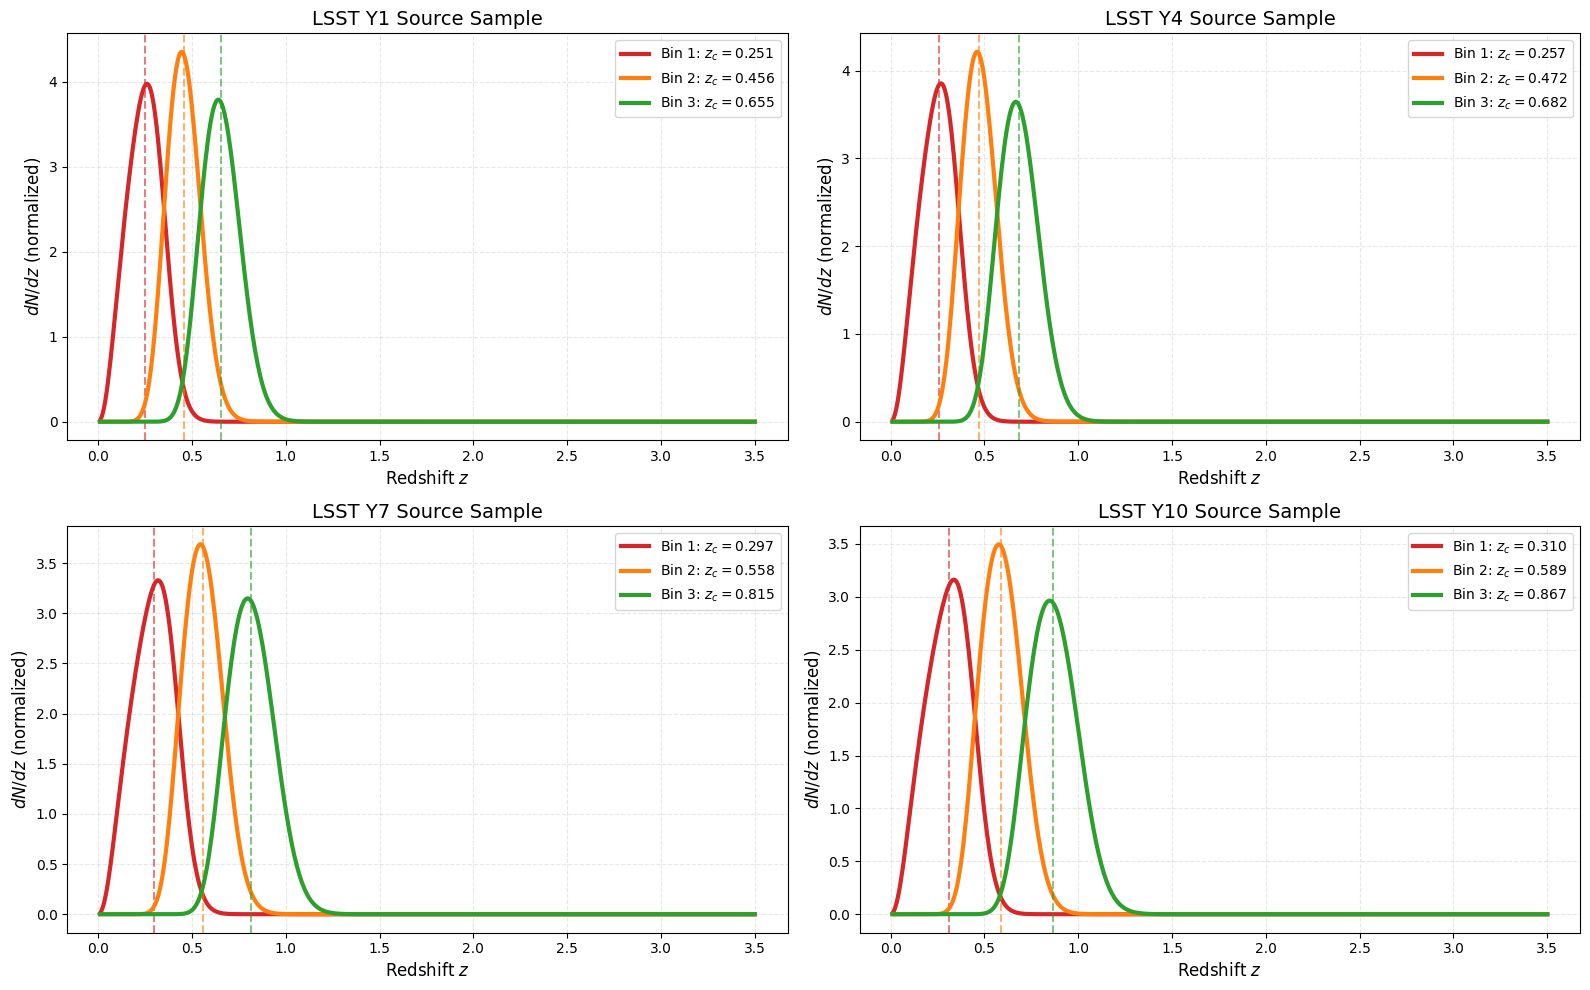

In [13]:
z_grid = np.linspace(Config.Z_MIN, Config.Z_MAX, Config.N_Z)

all_years_data = load_all_lsst_years(
    Config.LSST_YEARS, 
    z_grid, 
    bins_to_use=Config.LSST_BINS
)

print("Loaded LSST data for years:", list(all_years_data.keys()))
for year in Config.LSST_YEARS:
    print(f"Y{year} bin centers: {all_years_data[year]['centers']}")

fig_all_bins = plot_all_lsst_bins(z_grid, all_years_data)
plt.show()

- ## Initialize Cosmology

In [14]:
H0 = Config.COSMO_PARAMS["h"] * 100.0
Om_m = Config.COSMO_PARAMS["Omega_m"]

cosmo_ccl = ccl.Cosmology(
    Omega_c=Config.COSMO_PARAMS["Omega_m"] - Config.COSMO_PARAMS["Omega_b"],
    Omega_b=Config.COSMO_PARAMS["Omega_b"],
    h=Config.COSMO_PARAMS["h"],
    sigma8=Config.COSMO_PARAMS["sigma8"],
    n_s=Config.COSMO_PARAMS["n_s"],
    w0=Config.COSMO_PARAMS["w0"],
    wa=Config.COSMO_PARAMS["wa"],
    m_nu=Config.COSMO_PARAMS["M_nu"],
    transfer_function=Config.TRANSFER_FUNCTION
)


- ## Compute Matter Power Spectra

In [15]:
k, pk_nl_gr, Q_boost = initialize_bacco_emulator(Config.COSMO_PARAMS)
pk_interp_gr = create_power_spectrum_interpolator(k, pk_nl_gr)

emantis_emu = initialize_emantis_emulator()

  0% (0 of 358400) |                     | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (32768 of 358400) |#                | Elapsed Time: 0:00:00 ETA:   0:00:01
 22% (81920 of 358400) |###              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (196608 of 358400) |########        | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (358400 of 358400) |################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 1658880) |                    | Elapsed Time: 0:00:00 ETA:  --:--:--
  1% (32768 of 1658880) |                | Elapsed Time: 0:00:00 ETA:   0:00:05
  4% (81920 of 1658880) |                | Elapsed Time: 0:00:00 ETA:   0:00:04
 11% (196608 of 1658880) |#              | Elapsed Time: 0:00:00 ETA:   0:00:02
 25% (425984 of 1658880) |###            | Elapsed Time: 0:00:00 ETA:   0:00:01
 52% (868352 of 1658880) |#######        | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (1658880 of 1658880) |##############| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 1658880) |                   

- ## Pre-compute Redshift-Dependent Quantities

In [16]:
chi_vals = comoving_distance(z_grid, cosmo_ccl)
H_vals = hubble_parameter(z_grid, cosmo_ccl, H0)

D_vals = growth_factor(z_grid, cosmo_ccl)
D0 = growth_factor(0.0, cosmo_ccl)

Wkappa_vals = cmb_lensing_kernel(
    z_grid, cosmo_ccl, chi_vals, Om_m, H0, Config.C_LIGHT
)

validation_results = validate_growth_factor(z_grid, D_vals, D0)

- ## Compute Angular Power Spectra for All Years - GR

In [17]:
ell = np.logspace(np.log10(Config.ELL_MIN), np.log10(Config.ELL_MAX), Config.N_ELL)

k_min_safe = k.min() * Config.K_MIN_SAFETY
k_max_safe = k.max() * Config.K_MAX_SAFETY

all_results_gr = {}

for year in Config.LSST_YEARS:
    print(f"\n{'='*60}")
    print(f"Computing GR spectra for LSST Year {year}")
    print(f"{'='*60}")
    
    lsst_bins = all_years_data[year]['bins']
    Cl_gg_gr = []
    Cl_kg_gr = []
    
    for bin_idx, (key, dNdz) in enumerate(lsst_bins.items()):
        print(f"  Bin {key+1}...")
        
        Cl_gg = compute_Cl_galaxy_auto(
            ell, pk_interp_gr, cosmo_ccl, z_grid, dNdz,
            chi_vals, H_vals, D_vals, D0, Config.C_LIGHT,
            b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
            k_min=k_min_safe, k_max=k_max_safe
        )
        
        Cl_kg = compute_Cl_galaxy_cmb_cross(
            ell, pk_interp_gr, cosmo_ccl, z_grid, dNdz,
            chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.C_LIGHT,
            b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
            k_min=k_min_safe, k_max=k_max_safe
        )
        
        Cl_gg_gr.append(Cl_gg)
        Cl_kg_gr.append(Cl_kg)
    
    all_results_gr[year] = {
        'Cl_gg': Cl_gg_gr,
        'Cl_kg': Cl_kg_gr
    }
    
    print(f"  ✓ GR spectra complete for Year {year}")

print("\n" + "="*60)
print("All GR spectra computed!")
print("="*60)



Computing GR spectra for LSST Year 1
  Bin 1...
  Bin 2...
  Bin 3...
  ✓ GR spectra complete for Year 1

Computing GR spectra for LSST Year 4
  Bin 1...
  Bin 2...
  Bin 3...
  ✓ GR spectra complete for Year 4

Computing GR spectra for LSST Year 7
  Bin 1...
  Bin 2...
  Bin 3...
  ✓ GR spectra complete for Year 7

Computing GR spectra for LSST Year 10
  Bin 1...
  Bin 2...
  Bin 3...
  ✓ GR spectra complete for Year 10

All GR spectra computed!


- ## Compute Angular Power Spectra for All Years - f(R)

In [18]:
all_results_fr = {}

for year in Config.LSST_YEARS:
    print(f"\n{'='*60}")
    print(f"Computing f(R) spectra for LSST Year {year}")
    print(f"{'='*60}")
    
    lsst_bins = all_years_data[year]['bins']
    fr_results = {"gg": [], "kg": []}
    
    for bin_idx, (key, dNdz) in enumerate(lsst_bins.items()):
        print(f"  Bin {key+1}...")
        
        bin_results_gg = {}
        bin_results_kg = {}
        
        for logfR0_val in Config.FR_VALUES:
            pk_boost = compute_fR_boost(
                emantis_emu, Config.COSMO_PARAMS, logfR0_val, k, 
                aexp=Config.COSMO_PARAMS["aexp"]
            )
            pk_fR = pk_nl_gr * pk_boost
            pk_interp_fr = create_power_spectrum_interpolator(k, pk_fR)
            
            Cl_gg_fr = compute_Cl_galaxy_auto(
                ell, pk_interp_fr, cosmo_ccl, z_grid, dNdz,
                chi_vals, H_vals, D_vals, D0, Config.C_LIGHT,
                b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
                k_min=k_min_safe, k_max=k_max_safe
            )
            
            Cl_kg_fr = compute_Cl_galaxy_cmb_cross(
                ell, pk_interp_fr, cosmo_ccl, z_grid, dNdz,
                chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.C_LIGHT,
                b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
                k_min=k_min_safe, k_max=k_max_safe
            )
            
            bin_results_gg[logfR0_val] = Cl_gg_fr
            bin_results_kg[logfR0_val] = Cl_kg_fr
        
        fr_results["gg"].append(bin_results_gg)
        fr_results["kg"].append(bin_results_kg)
    
    all_results_fr[year] = fr_results
    print(f"  ✓ f(R) spectra complete for Year {year}")

print("\n" + "="*60)
print("All f(R) spectra computed!")
print("="*60)


Computing f(R) spectra for LSST Year 1
  Bin 1...
  Bin 2...
  Bin 3...
  ✓ f(R) spectra complete for Year 1

Computing f(R) spectra for LSST Year 4
  Bin 1...
  Bin 2...
  Bin 3...
  ✓ f(R) spectra complete for Year 4

Computing f(R) spectra for LSST Year 7
  Bin 1...
  Bin 2...
  Bin 3...
  ✓ f(R) spectra complete for Year 7

Computing f(R) spectra for LSST Year 10
  Bin 1...
  Bin 2...
  Bin 3...
  ✓ f(R) spectra complete for Year 10

All f(R) spectra computed!


- ## Plot Results for Year 1

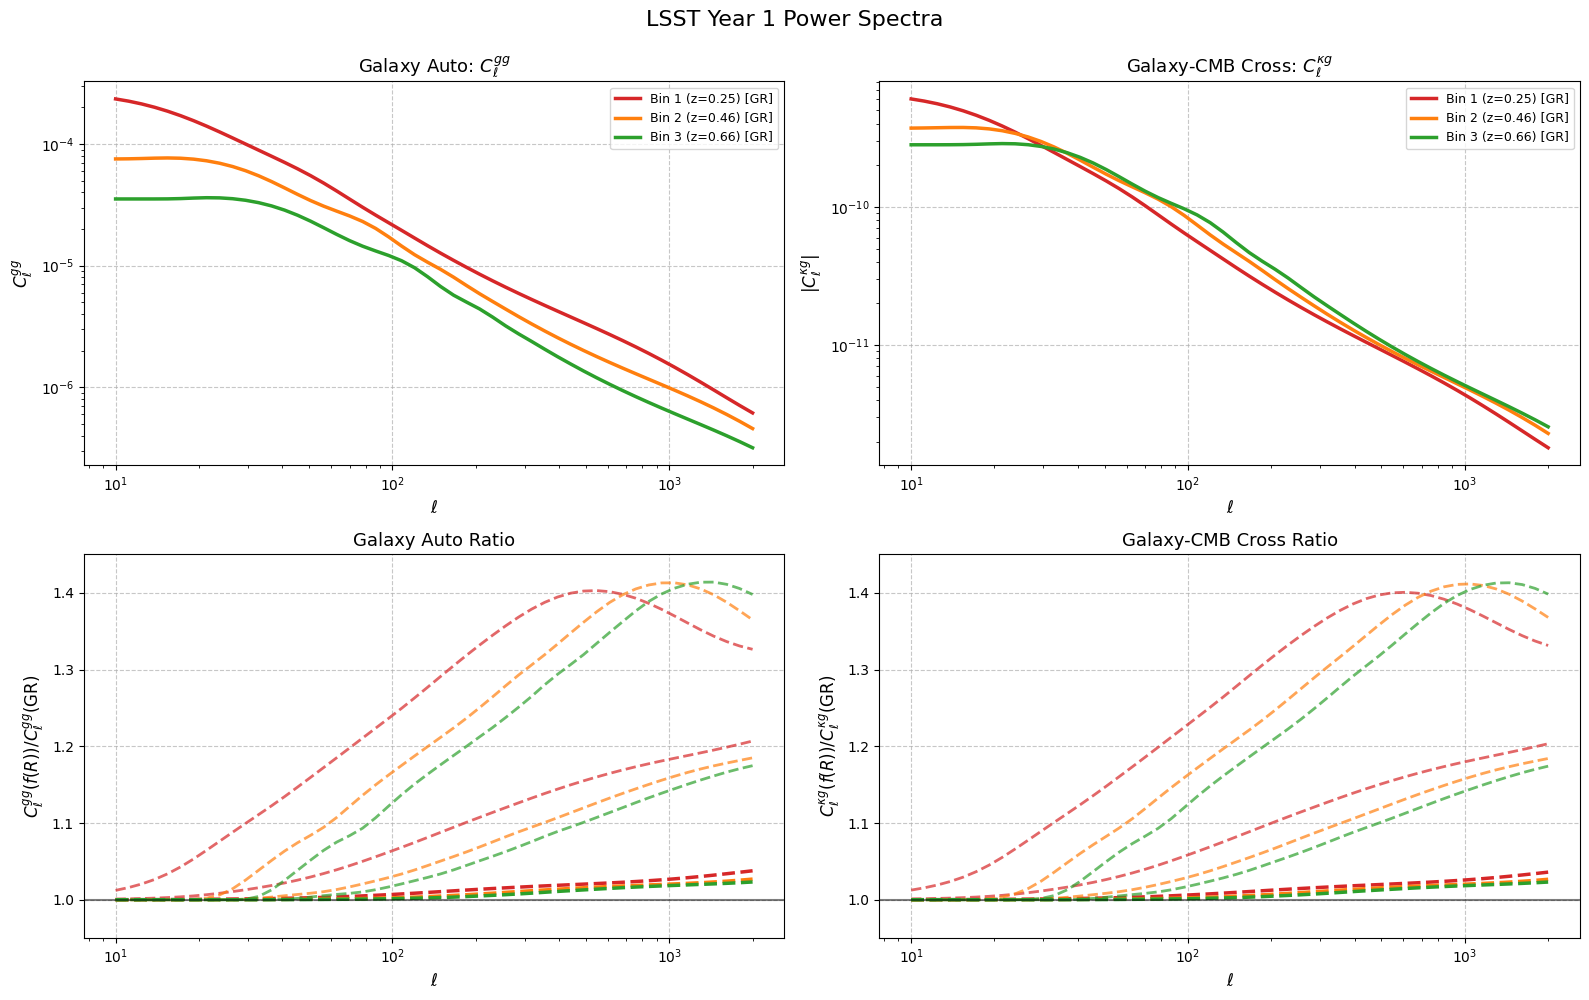

In [19]:
fig_y1 = plot_power_spectra_single_year(
    ell, "1",
    all_results_gr["1"]['Cl_gg'],
    all_results_gr["1"]['Cl_kg'],
    all_results_fr["1"],
    Config.FR_VALUES,
    all_years_data["1"]['centers']
)
plt.show()

- # Plot Results for Year 7

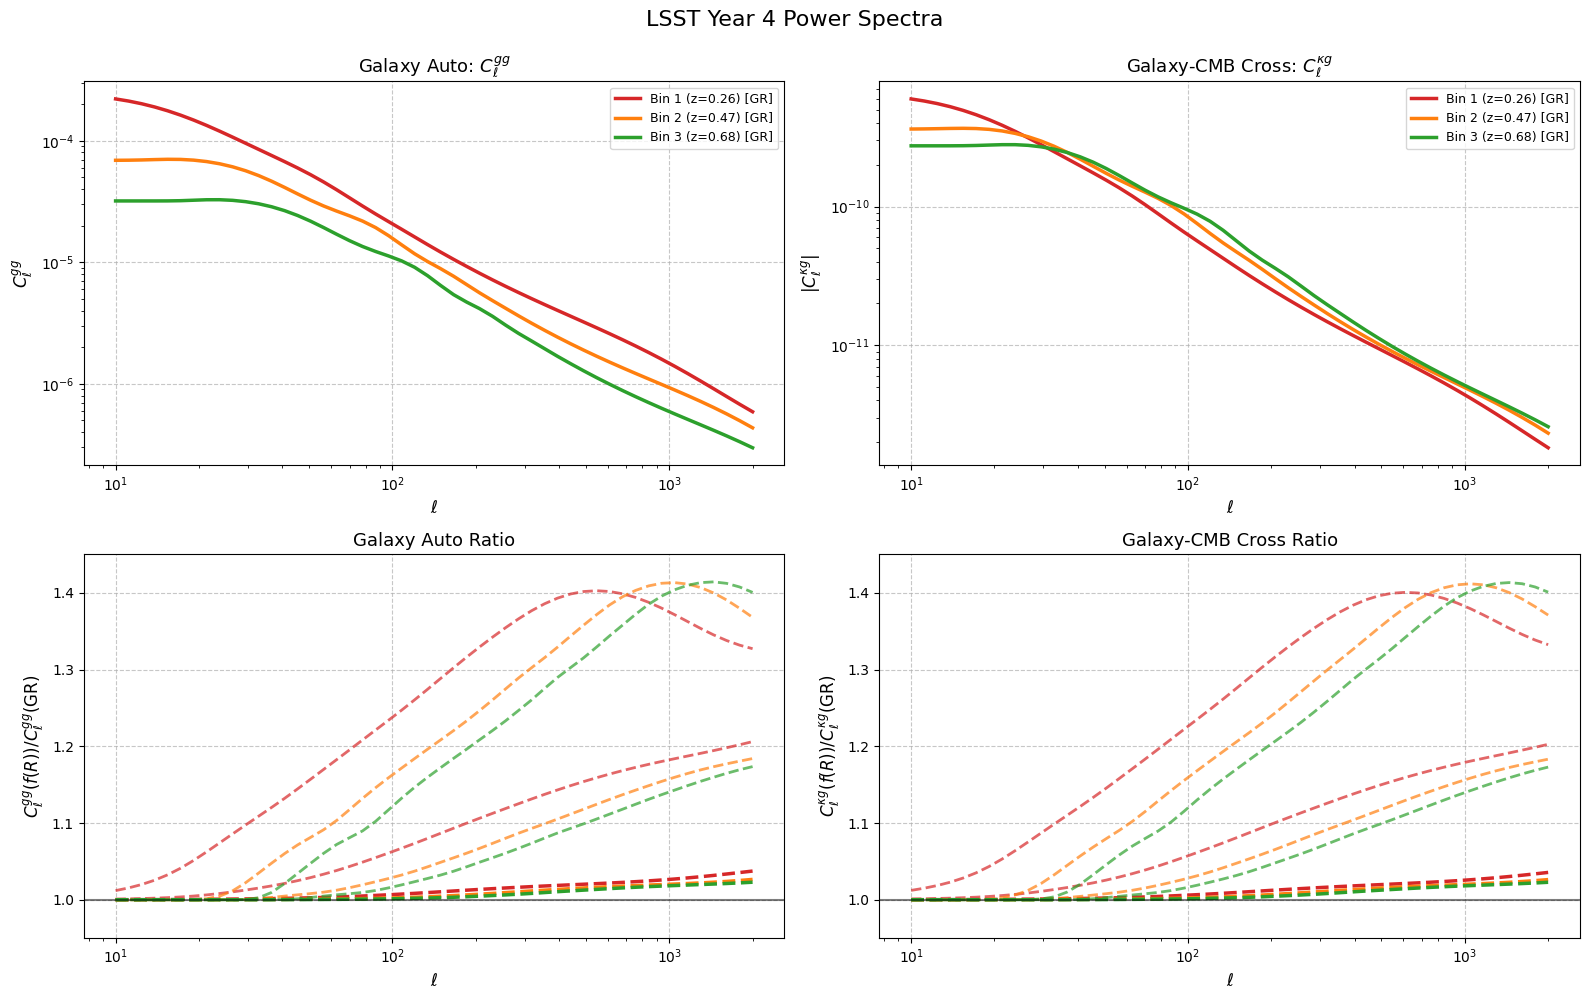

In [20]:
fig_y4 = plot_power_spectra_single_year(
    ell, "4",
    all_results_gr["4"]['Cl_gg'],
    all_results_gr["4"]['Cl_kg'],
    all_results_fr["4"],
    Config.FR_VALUES,
    all_years_data["4"]['centers']
)
plt.show()

- ## 

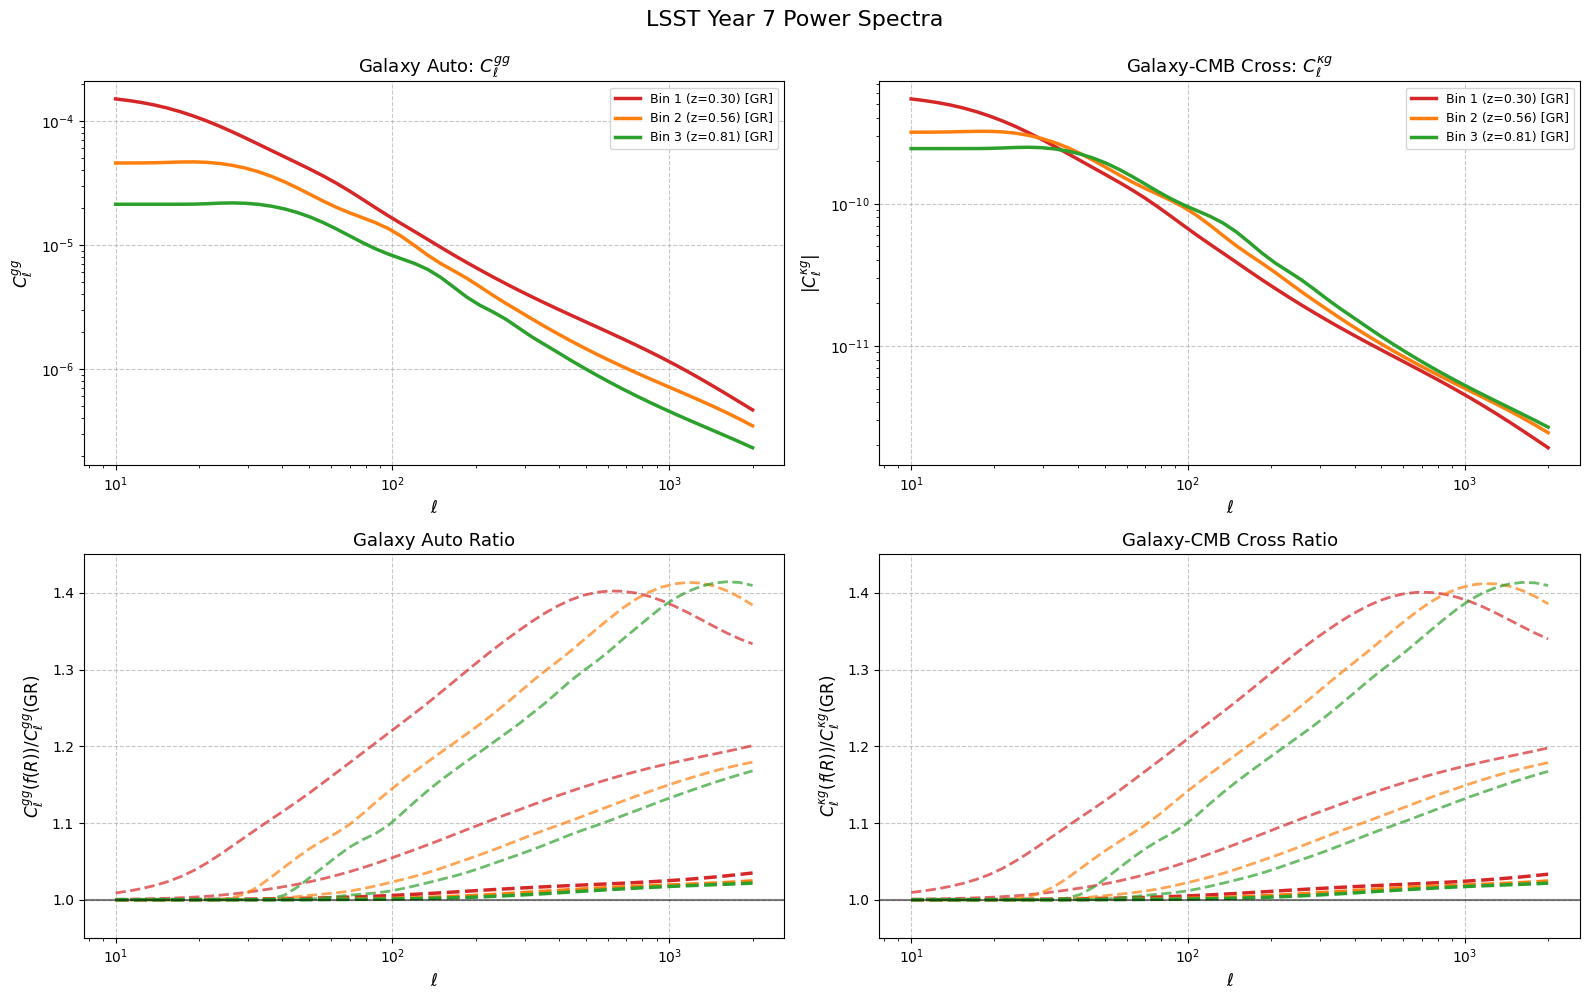

In [21]:
fig_y7 = plot_power_spectra_single_year(
    ell, "7",
    all_results_gr["7"]['Cl_gg'],
    all_results_gr["7"]['Cl_kg'],
    all_results_fr["7"],
    Config.FR_VALUES,
    all_years_data["7"]['centers']
)
plt.show()

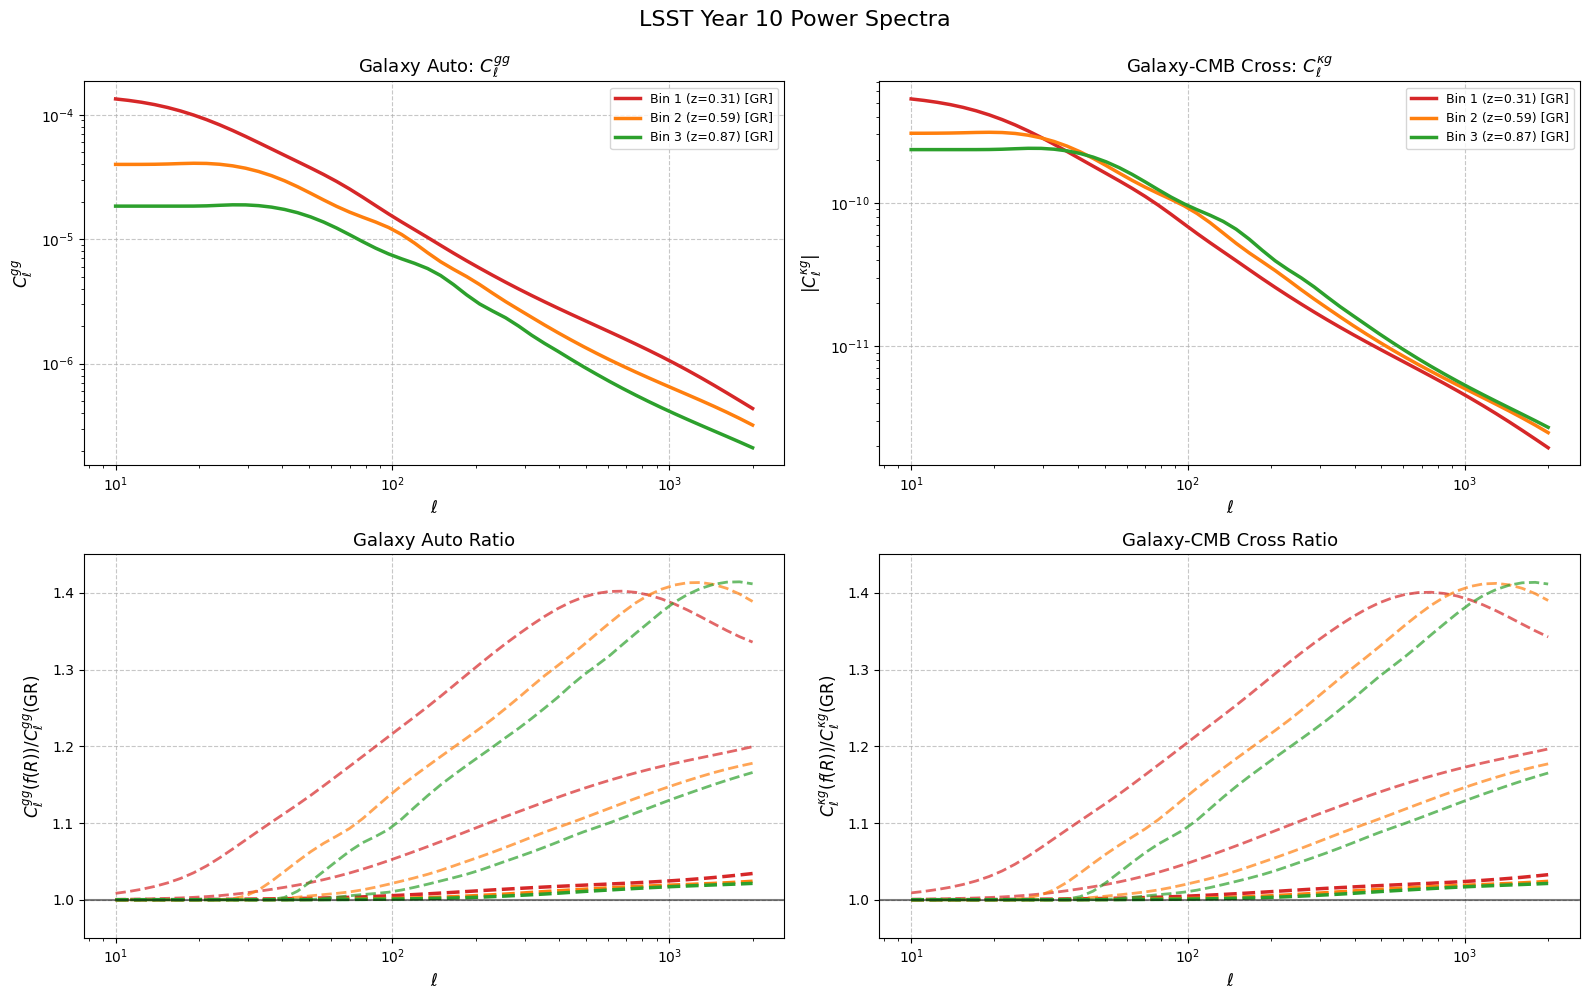


Analysis complete for all LSST years!


In [22]:
fig_y10 = plot_power_spectra_single_year(
    ell, "10",
    all_results_gr["10"]['Cl_gg'],
    all_results_gr["10"]['Cl_kg'],
    all_results_fr["10"],
    Config.FR_VALUES,
    all_years_data["10"]['centers']
)
plt.show()

print("\nAnalysis complete for all LSST years!")